In [1]:
!pip install -q kaggle tensorflow matplotlib opencv-python scikit-learn

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kowshik10","key":"8de6ff918db28d2b9be7ebb35f167324"}'}

In [3]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d dansbecker/cityscapes-image-pairs
!unzip -q cityscapes-image-pairs.zip -d /content/cityscapes

Dataset URL: https://www.kaggle.com/datasets/dansbecker/cityscapes-image-pairs
License(s): other
 56% 112M/202M [00:00<00:00, 1.11GB/s]
100% 202M/202M [00:00<00:00, 596MB/s] 


In [4]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

EPOCHS = 5
BATCH_SIZE = 8
HEIGHT = 256
WIDTH = 256
N_CLASSES = 13
TRAIN_PATH = "/content/cityscapes/cityscapes_data/cityscapes_data/train"
VALID_PATH = "/content/cityscapes/cityscapes_data/cityscapes_data/val"

# --- Data Preprocessing ---
def load_and_preprocess(file, path):
    img = Image.open(os.path.join(path, file))
    img = np.array(img)

    image = img[:, :256] / 255.0
    mask = img[:, 256:]

    bins = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240])
    mask_indices = np.digitize(mask[:,:,0], bins)

    return image, mask_indices

def data_generator(path, batch_size=BATCH_SIZE):
    files = os.listdir(path)
    while True:
        np.random.shuffle(files)
        for i in range(0, len(files), batch_size):
            batch_files = files[i : i+batch_size]
            imgs, segs = [], []
            for f in batch_files:
                img, mask = load_and_preprocess(f, path)
                imgs.append(img)
                segs.append(mask)
            yield np.array(imgs), np.expand_dims(np.array(segs), -1)

In [5]:
def build_unet_mobilenet(n_classes):
    # Encoder: Pre-trained MobileNetV2
    base_model = MobileNetV2(input_shape=(256, 256, 3), include_top=False, weights='imagenet')

    # Select skip connection layers
    skip_names = [
        'block_1_expand_relu',   # 128x128
        'block_3_expand_relu',   # 64x64
        'block_6_expand_relu',   # 32x32
        'block_13_expand_relu'   # 16x16
    ]
    skips = [base_model.get_layer(name).output for name in skip_names]

    # Create the sampling model
    down_stack = Model(inputs=base_model.input, outputs=skips)
    down_stack.trainable = False

    inputs = layers.Input(shape=(256, 256, 3))
    layer_outputs = down_stack(inputs)

    x = layer_outputs[-1] # Bottleneck
    reversed_skips = reversed(layer_outputs[:-1])

    # Decoder: Upsampling + Skip Connections
    for skip in reversed_skips:
        x = layers.UpSampling2D((2, 2))(x)
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)

    # Final Upscale to reach 256x256
    x = layers.UpSampling2D((2, 2))(x)
    outputs = layers.Conv2D(n_classes, 1, activation='softmax')(x)

    return Model(inputs, outputs)


/tmp/ipykernel_8391/832904045.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(256, 256, 3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
371/371 ━━━━━━━━━━━━━━━━━━━━ 73s 124ms/step - accuracy: 0.7494 - loss: 0.8696 - val_accuracy: 0.7562 - val_loss: 0.8689
Epoch 2/10
371/371 ━━━━━━━━━━━━━━━━━━━━ 60s 107ms/step - accuracy: 0.7737 - loss: 0.7537 - val_accuracy: 0.7371 - val_loss: 0.8641
Epoch 3/10
371/371 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.7809 - loss: 0.7218 - val_accuracy: 0.7642 - val_loss: 0.7857
Epoch 4/10
371/371 ━━━━━━━━━━━━━━━━━━━━ 53s 144ms/step - accuracy: 0.7850 - loss: 0.7025 - val_accuracy: 0.7718 - val_loss: 0.7606
Epoch 5/10
371/371 ━━━━━━━━━━━━━━━━━━━━ 41s 111ms/step - accuracy: 0.7886 - loss: 0.6876 - val_accuracy: 0.7683 - val_loss: 0.7634
Epoch 6/10
371/371 ━━━━━━━━━━━━━━━━━━━━ 40s 108ms/step - accuracy: 0.7923 - loss: 0.6736 - val_accuracy: 0.7704 - val_loss: 0.7684
Epoch 7/10
371/371 ━━━━━━━━━━━━━━━━━━━━ 40s 109ms/step - accuracy: 0.7949 - loss: 0.6629 - val_accuracy: 0.7782 - val_loss: 0.7503
Epoch 8/10
371/371 ━━━━━━━━━━━━━━━

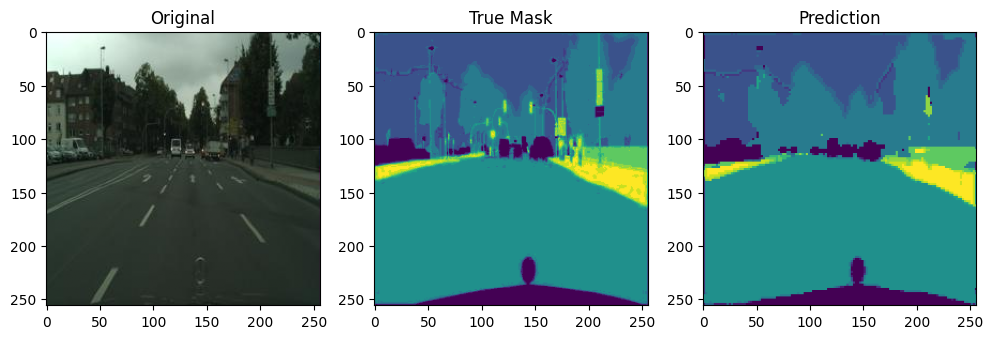

In [6]:
model = build_unet_mobilenet(N_CLASSES)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

train_gen = data_generator(TRAIN_PATH)
val_gen = data_generator(VALID_PATH)

steps_per_epoch = len(os.listdir(TRAIN_PATH)) // BATCH_SIZE
val_steps = len(os.listdir(VALID_PATH)) // BATCH_SIZE

model.fit(train_gen,
          steps_per_epoch=steps_per_epoch,
          validation_data=val_gen,
          validation_steps=val_steps,
          epochs=10)

def plot_predictions(gen):
    imgs, masks = next(gen)
    preds = model.predict(imgs)

    plt.figure(figsize=(12, 4))
    for i in range(1):
        plt.subplot(1, 3, 1); plt.imshow(imgs[i]); plt.title("Original")
        plt.subplot(1, 3, 2); plt.imshow(masks[i].squeeze()); plt.title("True Mask")
        plt.subplot(1, 3, 3); plt.imshow(np.argmax(preds[i], axis=-1)); plt.title("Prediction")
    plt.show()

plot_predictions(val_gen)